### PanACEA Btz-043 MBLA analysis
#### Biomarker PCA

- Developed by: Mairi McClean
- Affiliation: Institute of Computational Biology, Helmholtz Munich; Infection and Immunity Group, LMU Klinikum
- v260526
- Response to reviewer comments from CPT:PSP


### import modules

In [1]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
from matplotlib import pyplot as plt
from scipy import stats
from scipy import linalg
from tqdm import tqdm
import time
from ppca import PPCA
import matplotlib.cm as cm
np.random.seed(30)

## PCA
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

In [2]:
## LMM imports
# from statsmodels.formula.api import ols
# import statsmodels.api as sm
# import statsmodels.formula.api as smf
# from statsmodels.regression.mixed_linear_model import MixedLM
# #from sklearn.model_selection import train_test_split
# from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.tsa.stattools import adfuller

In [3]:
plt.rcParams['figure.figsize'] = [10, 8]

#### Read in data - TB-1014

##### Check for reasons for missing culture

##### Format data

In [4]:
## from data processing notebook in R; same data used for dose-response model; no outliers removed
cols=['USUBJID', 'DAY','ARM', 'logCFU', 'logTTP','AGE', 'SEX']
X = pd.read_csv('/Users/mairi.mcclean/Desktop/lva_phII/code_output/tb1014/data_man/250710mm_mb_dm.csv', index_col=0, usecols=cols)
### log values here are log10

In [73]:
study_ids = set(X['USUBJID'])
len(study_ids)

105

In [6]:
check=X.drop_duplicates(subset=['USUBJID'])
check['ARM'].value_counts()

ARM
CLOFAZIMINE                                     15
TMC207 + PA-824 + CLOFAZIMINE                   15
TMC207 + PA-824 + PYRAZINAMIDE                  15
TMC207 + PA-824 + PYRAZINAMIDE + CLOFAZIMINE    15
TMC207 + PYRAZINAMIDE + CLOFAZIMINE             15
Rifafour e-275                                  15
PYRAZINAMIDE                                    15
Name: count, dtype: int64

In [28]:
#    lambda x: x.iloc[:2].mean())
day0=X.loc[X['DAY'].isin([-2.0,-1.0])].groupby('USUBJID').agg({
    'logCFU':'mean',
    'logTTP':'mean',
    'DAY': lambda x:0,
    'ARM':'first',
    'SEX': 'first',
    'AGE': 'first'}).reset_index()

rest = X.loc[~X['DAY'].isin([-2.0,-1.0])]
X_=pd.concat([day0,rest], ignore_index=True)

In [29]:
treatment_window = [0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0]
X_ = X_[X_.DAY.isin(treatment_window)]
X_.shape

(1538, 7)

> Until this point, all NaN values are missing due to contamination/assay not done

In [ ]:
25*24 # ULQ for TTP from Dufault == 600 hours
## My ttp here is in hours 
print(np.log(600))
print(np.log10(600))

6.396929655216146
2.7781512503836434


In [32]:
print((X_.logCFU <= 0.0).sum())
print((X_.logCFU.isna()).sum())

print((X_.logTTP >= 2.77).sum())
print((X_.logTTP.isna()).sum())
print(X_.shape)

print(((X_.logTTP.isna()) & (X_.logCFU.isna())).sum())

53
56
16
45
(1538, 7)
28


In [58]:
X_

,USUBJID,logCFU,logTTP,DAY,ARM,SEX,AGE
0,TB-1014/1001,6.232729,1.955399,0.0,TMC207 + PA-824 + PYRAZINAMIDE + CLOFAZIMINE,M,35.0
1,TB-1014/1002,6.367256,2.186540,0.0,PYRAZINAMIDE,M,57.0
2,TB-1014/1003,5.098558,1.976258,0.0,Rifafour e-275,F,25.0
3,TB-1014/1004,4.774133,2.056027,0.0,TMC207 + PYRAZINAMIDE + CLOFAZIMINE,F,23.0
4,TB-1014/1005,5.758466,1.940103,0.0,CLOFAZIMINE,M,24.0
...,...,...,...,...,...,...,...
1857,TB-1014/2002,NaN,NaN,10.0,PYRAZINAMIDE,F,26.0
1858,TB-1014/2002,NaN,NaN,12.0,PYRAZINAMIDE,F,26.0
1869,TB-1014/1002,NaN,NaN,4.0,PYRAZINAMIDE,M,57.0
1879,TB-1014/2080,NaN,NaN,11.0,PYRAZINAMIDE,F,37.0


In [34]:
#### DROP ROW FOR PATIENT
Xcfu = X_.drop(columns=['logTTP'])
Xcfu = Xcfu[ np.logical_or(X_['logCFU'] > 0.0, np.isnan(X_['logCFU'])) ]
Xcfu

,USUBJID,logCFU,DAY,ARM,SEX,AGE
0,TB-1014/1001,6.232729,0.0,TMC207 + PA-824 + PYRAZINAMIDE + CLOFAZIMINE,M,35.0
1,TB-1014/1002,6.367256,0.0,PYRAZINAMIDE,M,57.0
2,TB-1014/1003,5.098558,0.0,Rifafour e-275,F,25.0
3,TB-1014/1004,4.774133,0.0,TMC207 + PYRAZINAMIDE + CLOFAZIMINE,F,23.0
4,TB-1014/1005,5.758466,0.0,CLOFAZIMINE,M,24.0
...,...,...,...,...,...,...
1857,TB-1014/2002,NaN,10.0,PYRAZINAMIDE,F,26.0
1858,TB-1014/2002,NaN,12.0,PYRAZINAMIDE,F,26.0
1869,TB-1014/1002,NaN,4.0,PYRAZINAMIDE,M,57.0
1879,TB-1014/2080,NaN,11.0,PYRAZINAMIDE,F,37.0


In [35]:
#### DROP ROW FOR PATIENT
Xttp = X_.drop(columns=['logCFU'])
Xttp = Xttp[ np.logical_or(X_['logTTP'] < 2.77, np.isnan(X_['logTTP'])) ]
Xttp

,USUBJID,logTTP,DAY,ARM,SEX,AGE
0,TB-1014/1001,1.955399,0.0,TMC207 + PA-824 + PYRAZINAMIDE + CLOFAZIMINE,M,35.0
1,TB-1014/1002,2.186540,0.0,PYRAZINAMIDE,M,57.0
2,TB-1014/1003,1.976258,0.0,Rifafour e-275,F,25.0
3,TB-1014/1004,2.056027,0.0,TMC207 + PYRAZINAMIDE + CLOFAZIMINE,F,23.0
4,TB-1014/1005,1.940103,0.0,CLOFAZIMINE,M,24.0
...,...,...,...,...,...,...
1857,TB-1014/2002,NaN,10.0,PYRAZINAMIDE,F,26.0
1858,TB-1014/2002,NaN,12.0,PYRAZINAMIDE,F,26.0
1869,TB-1014/1002,NaN,4.0,PYRAZINAMIDE,M,57.0
1879,TB-1014/2080,NaN,11.0,PYRAZINAMIDE,F,37.0


In [36]:
print((Xcfu.logCFU <= 0.0).sum())
print((Xcfu.logCFU.isna()).sum())
print(Xcfu.shape)


print((Xttp.logTTP >= 2.77).sum())
print((Xttp.logTTP.isna()).sum())
print(Xttp.shape)

0
56
(1485, 6)
0
45
(1522, 6)


In [69]:
### Merge and check for introduction of NAs
X_full = pd.merge(Xttp,Xcfu, on=['USUBJID', 'DAY', 'ARM', 'SEX','AGE'], how='outer',indicator=True)

In [70]:
X_full['_merge'].value_counts()
## left only - 45 in TTP without CFU (includes 2 missing TTP values)
## right only - 8 missing TTP but with CFU 

_merge
both          1477
left_only       45
right_only       8
Name: count, dtype: int64

In [ ]:
X_full = X_full.drop(columns=['_merge'])
print(X_full.shape)

(1530, 7)


### Calculate CV 

In [79]:
assays = X_full.columns.difference(['USUBJID', 'DAY', 'ARM', 'SEX', 'AGE'])

# Step 1: Calculate the overall CV for each assay
overall_cv = X_full[assays].std() / X_full[assays].mean() * 100

# Step 2: Calculate the CV for each assay at each timepoint
cv_by_timepoint = X_full.groupby('DAY').apply(lambda group: group[assays].std() / group[assays].mean() * 100)

# Results for Step 2 in a table format (rows: timepoints, columns: assays)
cv_by_timepoint_table = cv_by_timepoint.reset_index()

print("Overall CV for each assay:")
print(overall_cv)
print("\nCV for each assay at each timepoint:")
print(cv_by_timepoint_table)

Overall CV for each assay:
logCFU    21.788850
logTTP     8.659892
dtype: float64

CV for each assay at each timepoint:
     DAY     logCFU    logTTP
0    0.0  15.654610  5.647645
1    1.0  17.086268  6.534738
2    2.0  17.987645  7.173046
3    3.0  19.446658  7.191010
4    4.0  19.310623  7.856289
5    5.0  18.631677  7.052689
6    6.0  19.118404  7.714086
7    7.0  21.545098  8.036470
8    8.0  21.658212  8.046118
9    9.0  22.595486  8.530287
10  10.0  25.190675  8.550472
11  11.0  25.574781  8.903318
12  12.0  23.697580  8.730575
13  13.0  23.621839  8.973628
14  14.0  26.983044  8.502641


/var/folders/wg/hnt896n13dqfsfm8dl5w3f9c0000gn/T/ipykernel_1715/1640198486.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cv_by_timepoint = X_full.groupby('DAY').apply(lambda group: group[assays].std() / group[assays].mean() * 100)


<Axes: xlabel='logCFU', ylabel='logTTP'>

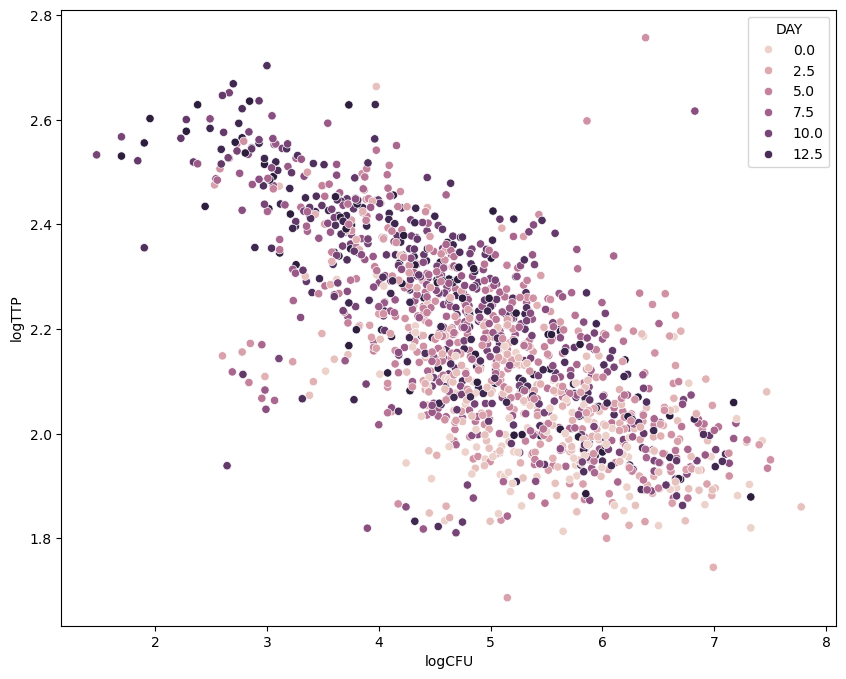

In [78]:
sns.scatterplot(data = X_full, x='logCFU',y='logTTP',hue='DAY')

> Is correlation time-dependent?

## pPCA

- Check if data is stationary

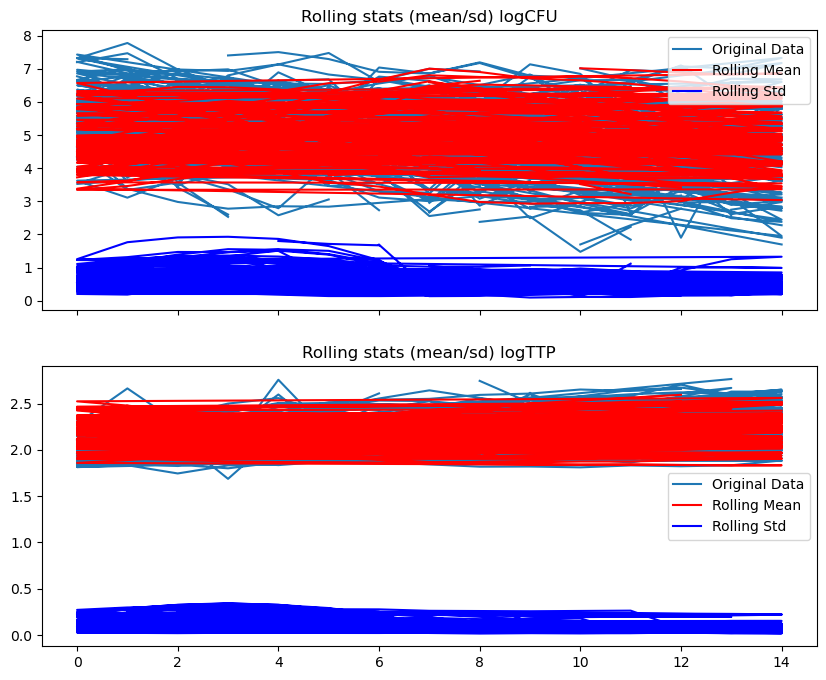

In [80]:
# Get a rolling mean per person
rolling_mean0 = X_full['logCFU'].rolling(window=8).mean() 
rolling_std0 = X_full['logCFU'].rolling(window=8).std()

rolling_mean1 = X_full['logTTP'].rolling(window=8).mean() 
rolling_std1 = X_full['logTTP'].rolling(window=8).std()

fig, (ax1, ax2) = plt.subplots(2, sharex=True)
ax1.plot(X_full['DAY'], X_full['logCFU'], label='Original Data')
ax1.plot(X_full['DAY'],rolling_mean0, color='red', label='Rolling Mean')
ax1.plot(X_full['DAY'],rolling_std0, color='blue', label='Rolling Std')
ax1.set_title('Rolling stats (mean/sd) logCFU')
ax1.legend()


ax2.plot(X_full['DAY'], X_full['logTTP'], label='Original Data')
ax2.plot(X_full['DAY'],rolling_mean1, color='red', label='Rolling Mean')
ax2.plot(X_full['DAY'],rolling_std1, color='blue', label='Rolling Std')
ax2.set_title('Rolling stats (mean/sd) logTTP')
ax2.legend()

plt.show()


In [81]:
## Stats models version - 
check = X_full['logTTP'].dropna()
# Run the ADF test
adfuller(check)
## data is stationary IF P-VAL IS SIGNIFICANT AND WE CAN REJECT H0 - no need to do first difference

(np.float64(-11.302241445700727),
 np.float64(1.298894381235709e-20),
 1,
 1475,
 {'1%': np.float64(-3.434791163965702),
  '5%': np.float64(-2.8635014840083945),
  '10%': np.float64(-2.5678142741740877)},
 np.float64(-2087.017587140653))

In [82]:
pp_df = X_full.drop(columns=['ARM', 'SEX','AGE'])
#pp_df['Day_scale'] = pp_df['Day']
cols = ['logTTP','logCFU'] #'Day_scale',
subset_df = pp_df[cols]
cs_df = (subset_df - subset_df.mean(0)) / subset_df.std(0) # centre/scale without df grouping
pp_df[cols] = cs_df
pp_df = pp_df.set_index(['USUBJID','DAY'])

In [83]:
pp_df.dropna(axis=0, subset=['logCFU', 'logTTP'], how='all', inplace=True) # drop instances of no values
pp_df

logTTP    logCFU
USUBJID      DAY                     
TB-1014/1001 0.0  -1.185624  1.203097
             1.0  -0.686824  1.351769
             2.0  -0.852830  0.998733
             3.0  -0.497694  0.636656
             4.0  -0.314533 -0.442221
...                     ...       ...
TB-1014/2087 10.0  1.845594 -2.123648
             11.0  1.782425 -2.181408
             12.0  1.793354 -0.962033
             13.0  1.930899 -2.181408
             14.0  1.647956       NaN

[1500 rows x 2 columns]

In [84]:
ppca = PPCA()
ppca.fit(pp_df.values, d=2) #(verbose=True) == convergence output # d== n components

In [ ]:
variance_explained = ppca.var_exp
components = ppca.data # imputed values
model_params = ppca.C # loadings?
component_mat = ppca.transform() # get components

pp_df['pc1'] = component_mat[:,0] # add PC1 to og df
pp_df['pc2'] = component_mat[:,1] # add PC2 to og df
print(variance_explained)

[0.83873392 1.00066711]


In [86]:
model_params # LOADINGS (features x pcs)

array([[ 0.71568904,  0.69841907],
       [-0.69841907,  0.71568904]])

In [87]:
pp_df=pp_df.reset_index()

In [94]:
pp_df_full = pd.merge(pp_df, X_full[['USUBJID','DAY', 'ARM', 'SEX', 'AGE']], on=['USUBJID','DAY'], how='left')

#### Plots

In [95]:
plt.rcParams['figure.figsize'] = [8, 4]

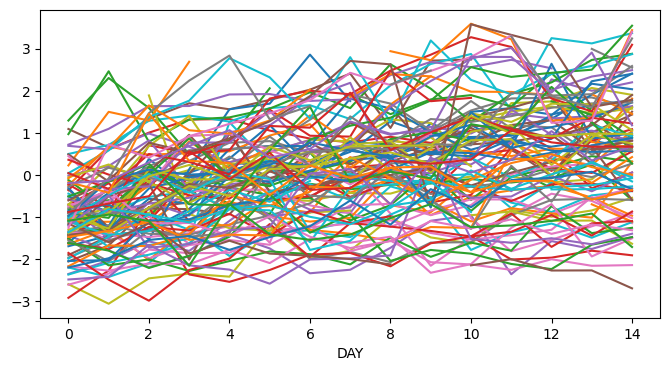

In [96]:
test = pp_df_full[["USUBJID", "DAY", "pc1", 'pc2', "ARM"]]
df_plot = pd.pivot(test, index="DAY", columns="USUBJID", values="pc1")
pl = df_plot.plot.line()
pl.legend().remove()
plt.show()

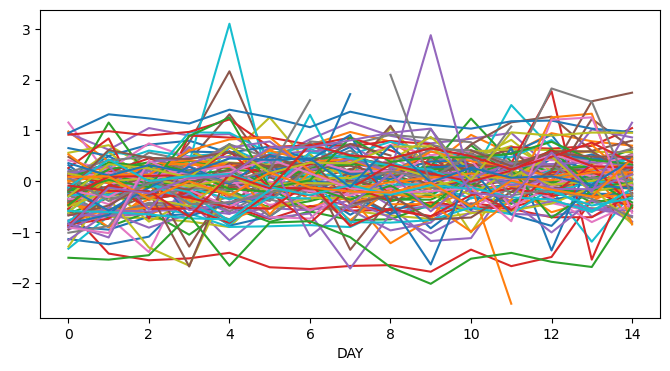

In [97]:
test = pp_df_full[["USUBJID", "DAY", 'pc2', "ARM"]]
df_plot = pd.pivot(test, index="DAY", columns="USUBJID", values="pc2")
#df_plot.index += 1
pl = df_plot.plot.line()
pl.legend().remove()
plt.show()

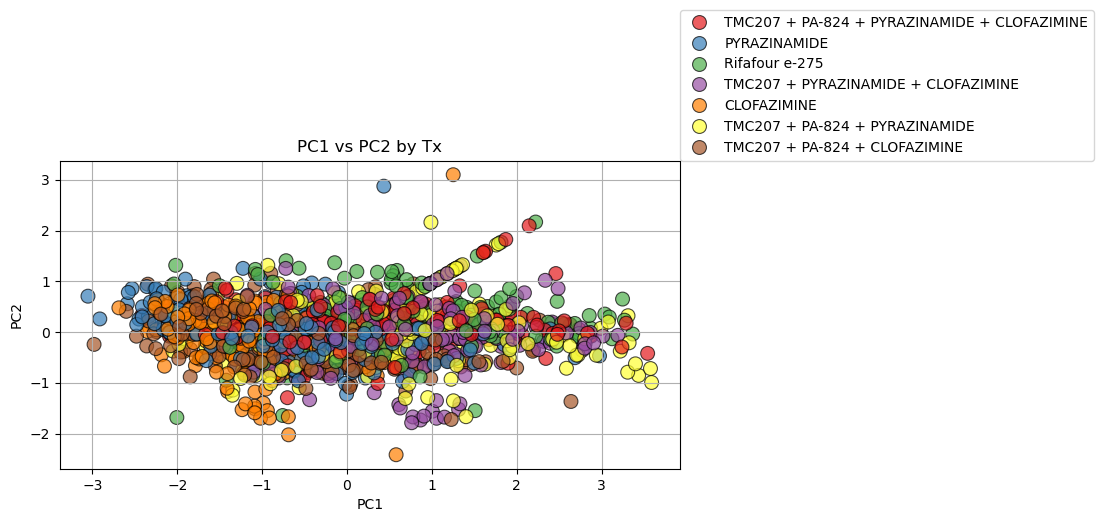

In [98]:
# Subset for just phase 2
sns.scatterplot(
    x='pc1', y='pc2',
    hue='ARM', 
    data=pp_df_full, 
    palette='Set1',
    s=100, 
    edgecolor='k',
    alpha=0.7
)
# Add labels and title
plt.title('PC1 vs PC2 by Tx')
plt.xlabel('PC1')
plt.ylabel('PC2')

# Show the plot
plt.legend(loc=(1, 1))
plt.grid(True)
plt.show()

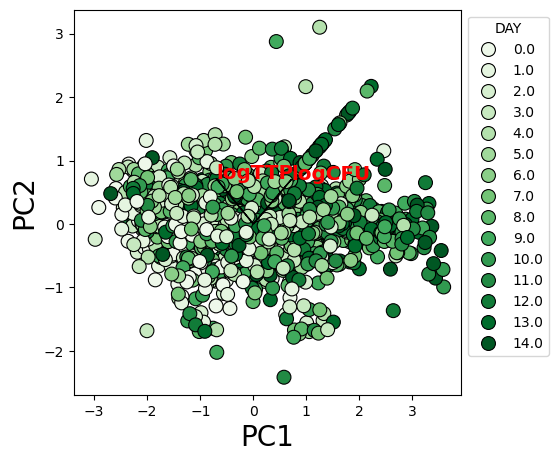

In [99]:
fig , ax = plt.subplots(1, 1, figsize=(5, 5))

cmap = sns.color_palette("Greens", n_colors=15)
sns.scatterplot(
    x='pc1', y='pc2', 
    hue='DAY',  
    data=pp_df_full, 
    palette=cmap,
    s=100, 
    edgecolor='k',
    alpha=1,
    ax=ax)

i, j = 0, 1 # which components
ax.set_xlabel('PC%d' % (i+1),fontsize=20)
ax.set_ylabel('PC%d' % (j+1),fontsize=20)


assays = pp_df_full[['logCFU','logTTP']]

for k in range(ppca.C.T.shape[1]):
    ax.arrow(0, 0, ppca.C.T[i,k], ppca.C.T[j,k])
    ax.text(ppca.C.T[i,k],
            ppca.C.T[j,k],
            assays.columns[k], 
            fontsize="x-large", 
            fontweight="bold",
            color='red')
    sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
    
plt.show()

In [100]:
loadings_df = pd.DataFrame(ppca.C)

In [101]:
loadings_df

,0,1
0,0.715689,0.698419
1,-0.698419,0.715689


- Check PCA by day

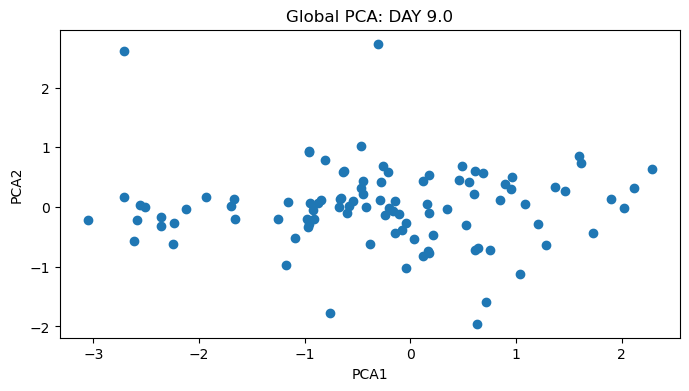

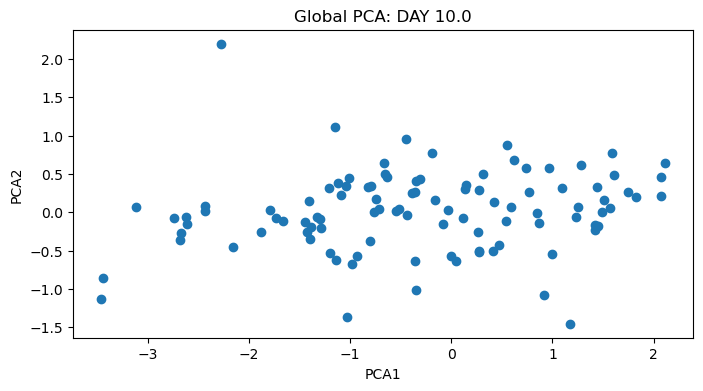

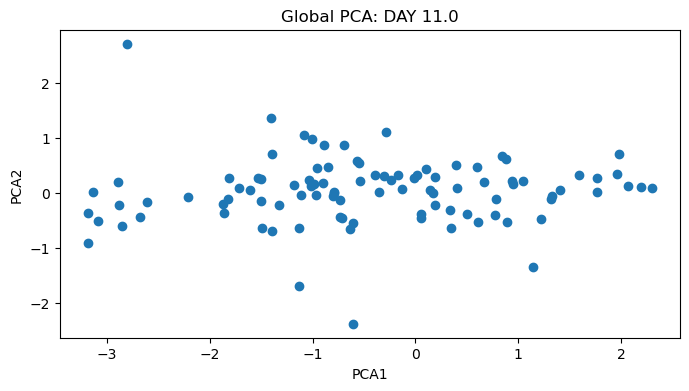

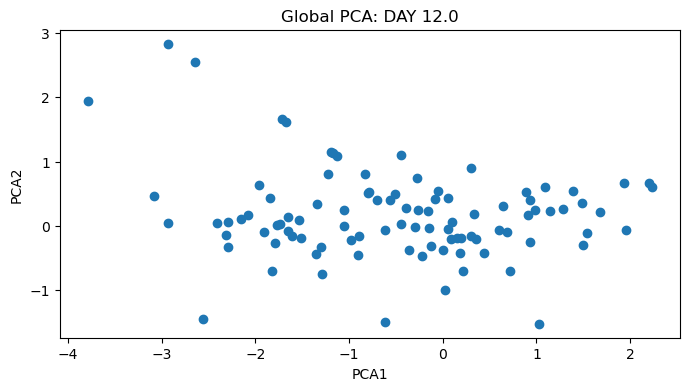

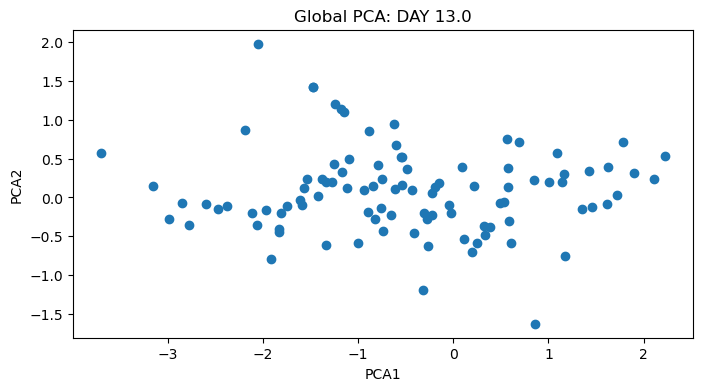

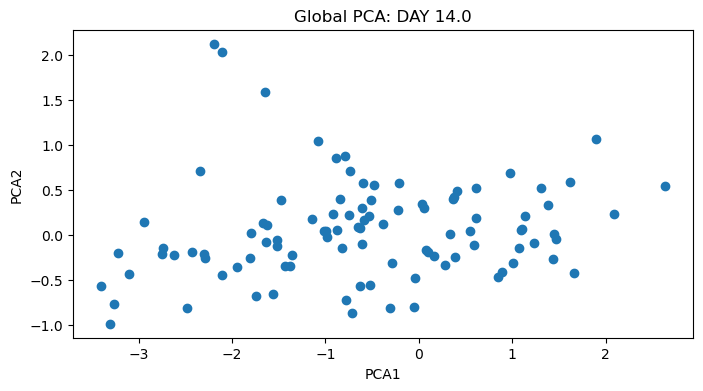

In [80]:
for day in pp_df['DAY'].unique()[9:]:

    fig = plt.figure()
    ax = fig.add_subplot()

    plt.title(f"Global PCA: DAY {day}")


    ax.set_xlabel('PCA1')
    ax.set_ylabel('PCA2')
    time_slice = pp_df[pp_df["DAY"] == day]

    original_features = time_slice[["pc1","pc2"]].to_numpy()
    xs = original_features.T[0]
    ys = original_features.T[1]

    ax.scatter(xs, ys)
    plt.show()   

In [102]:
### Write out data
#pp_df_full.to_csv("/Users/mairi.mcclean/Desktop/btz/manuscript_posters/CPT_PSP_submission/submitted/revisions/extra_analysis/processed_data/260526mm_pPCA_TB1014.csv")
pp_df_full.to_csv("/Users/mairi.mcclean/Desktop/btz/manuscript_posters/CPT_PSP_submission/submitted/revisions/extra_analysis/processed_data/260608mm_pPCA_TB1014_ALL_REMOVED.csv")

In [26]:
## Raw data (logCFU and TTP)
X_.to_csv("/Users/mairi.mcclean/Desktop/btz/manuscript_posters/CPT_PSP_submission/submitted/revisions/extra_analysis/processed_data/2600605mm_TB1014_raw.csv",index=False)

## Sensitivity analysis

> vary TTP missingness
> vary together 

In [43]:
missing_proportions = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

## only for patients that have logMBLA present
assay = 'logTTP'
# Apply missing values for each proportion
for proportion in missing_proportions:
    new_col = f'{assay}_missing_{int(proportion * 100)}'
    pp_df[new_col] = pp_df[assay]
    valid_rows = pp_df[pp_df['logCFU'].notna()].index
    missing_indices = np.random.choice(valid_rows, size=int(proportion * len(valid_rows)), replace=False)
    pp_df.loc[missing_indices, new_col] = np.nan
pp_df

,USUBJID,DAY,logCFU,logTTP,pc1_100,logCFU_missing_10,logCFU_missing_20,logCFU_missing_30,logCFU_missing_40,logCFU_missing_50,...,pc1_CFU50,logTTP_missing_10,logTTP_missing_20,logTTP_missing_30,logTTP_missing_40,logTTP_missing_50,logTTP_missing_60,logTTP_missing_70,logTTP_missing_80,logTTP_missing_90
0,TB-1014/1001,0.0,1.203097,-1.141786,1.657641,NaN,1.203097,1.203097,NaN,1.203097,...,1.584245,-1.141786,-1.141786,-1.141786,-1.141786,-1.141786,NaN,-1.141786,NaN,NaN
1,TB-1014/1002,0.0,1.328125,-0.002710,0.924861,1.328125,1.328125,1.328125,1.328125,1.328125,...,0.685701,-0.002710,-0.002710,-0.002710,NaN,NaN,NaN,NaN,NaN,NaN
2,TB-1014/1003,0.0,0.149016,-1.038991,0.851192,0.149016,0.149016,NaN,0.149016,0.149016,...,0.937034,-1.038991,-1.038991,-1.038991,NaN,NaN,NaN,NaN,NaN,NaN
3,TB-1014/1004,0.0,-0.152499,-0.645885,0.358797,-0.152499,-0.152499,-0.152499,NaN,NaN,...,0.648117,-0.645885,NaN,NaN,NaN,-0.645885,-0.645885,-0.645885,-0.645885,NaN
4,TB-1014/1005,0.0,0.762325,-1.217166,1.405591,0.762325,0.762325,0.762325,NaN,NaN,...,1.221372,NaN,-1.217166,-1.217166,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1503,TB-1014/2082,10.0,-0.075175,-0.641560,0.409418,-0.075175,-0.075175,NaN,-0.075175,NaN,...,0.643777,-0.641560,NaN,-0.641560,NaN,NaN,NaN,NaN,NaN,NaN
1504,TB-1014/2082,11.0,0.106749,-0.130897,0.168371,0.106749,0.106749,0.106749,NaN,0.106749,...,0.145270,-0.130897,-0.130897,-0.130897,-0.130897,-0.130897,-0.130897,-0.130897,NaN,NaN
1505,TB-1014/2082,12.0,-0.027634,-0.236384,0.150895,-0.027634,NaN,NaN,-0.027634,NaN,...,0.237201,-0.236384,-0.236384,-0.236384,-0.236384,NaN,-0.236384,NaN,NaN,NaN
1506,TB-1014/2082,13.0,0.190334,-0.625848,0.582613,0.190334,0.190334,0.190334,0.190334,0.190334,...,0.608990,-0.625848,-0.625848,-0.625848,NaN,-0.625848,NaN,NaN,NaN,NaN


In [48]:
df = pp_df[['logCFU','logTTP_missing_50']]
ppca_missing = PPCA()
ppca_missing.fit(df.values, d=2) #(verbose=True) == convergence output # d==n components
variance_explained = ppca_missing.var_exp
print(variance_explained)

components = ppca_missing.data # imputed values
model_params = ppca_missing.C # loadings?
component_mat = ppca_missing.transform() # get components
pp_df['pc1_TTP50'] = component_mat[:,0] # add PC1 to og df

[0.84552181 1.00066357]


In [50]:
missing_props = [0.05,0.1,0.15,0.2,0.25,0.3,0.35,0.4,0.45,0.5]

## only for patients that have logMBLA present
assay1 = 'logCFU'
assay2 = 'logTTP'

# Apply missing values for each proportion
for proportion in missing_props:
    new_CFUcol = f'{assay1}_missing_{int(proportion * 100)}'
    new_TTPcol = f'{assay2}_missing_{int(proportion * 100)}'

    pp_df[new_CFUcol] = pp_df[assay1]
    pp_df[new_TTPcol] = pp_df[assay2]

    valid_CFUrows = pp_df[pp_df['logCFU'].notna()].index
    missing_TTPindices = np.random.choice(valid_CFUrows, size=int(proportion * len(valid_CFUrows)), replace=False)
    pp_df.loc[missing_TTPindices, new_CFUcol] = np.nan

    valid_TTProws = pp_df[pp_df['logTTP'].notna()].index
    missing_CFUindices = np.random.choice(valid_TTProws, size=int(proportion * len(valid_TTProws)), replace=False)
    pp_df.loc[missing_CFUindices, new_TTPcol] = np.nan

pp_df

,USUBJID,DAY,logCFU,logTTP,pc1_100,logCFU_missing_10,logCFU_missing_20,logCFU_missing_30,logCFU_missing_40,logCFU_missing_50,...,logCFU_missing_5,logTTP_missing_5,logCFU_missing_15,logTTP_missing_15,logCFU_missing_25,logTTP_missing_25,logCFU_missing_35,logTTP_missing_35,logCFU_missing_45,logTTP_missing_45
0,TB-1014/1001,0.0,1.203097,-1.141786,1.657641,1.203097,1.203097,NaN,NaN,NaN,...,1.203097,NaN,1.203097,-1.141786,1.203097,-1.141786,1.203097,NaN,1.203097,NaN
1,TB-1014/1002,0.0,1.328125,-0.002710,0.924861,1.328125,1.328125,1.328125,NaN,NaN,...,1.328125,-0.002710,1.328125,-0.002710,1.328125,-0.002710,1.328125,NaN,1.328125,NaN
2,TB-1014/1003,0.0,0.149016,-1.038991,0.851192,0.149016,0.149016,NaN,NaN,0.149016,...,0.149016,-1.038991,0.149016,NaN,0.149016,-1.038991,0.149016,-1.038991,NaN,-1.038991
3,TB-1014/1004,0.0,-0.152499,-0.645885,0.358797,-0.152499,NaN,-0.152499,-0.152499,NaN,...,-0.152499,-0.645885,-0.152499,-0.645885,NaN,-0.645885,-0.152499,NaN,-0.152499,NaN
4,TB-1014/1005,0.0,0.762325,-1.217166,1.405591,0.762325,0.762325,0.762325,0.762325,0.762325,...,0.762325,-1.217166,0.762325,-1.217166,NaN,-1.217166,NaN,-1.217166,NaN,-1.217166
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1503,TB-1014/2082,10.0,-0.075175,-0.641560,0.409418,-0.075175,-0.075175,NaN,-0.075175,NaN,...,-0.075175,-0.641560,-0.075175,-0.641560,-0.075175,NaN,-0.075175,NaN,-0.075175,-0.641560
1504,TB-1014/2082,11.0,0.106749,-0.130897,0.168371,0.106749,0.106749,0.106749,0.106749,0.106749,...,0.106749,-0.130897,0.106749,-0.130897,0.106749,NaN,0.106749,-0.130897,NaN,NaN
1505,TB-1014/2082,12.0,-0.027634,-0.236384,0.150895,NaN,-0.027634,NaN,-0.027634,NaN,...,-0.027634,-0.236384,-0.027634,-0.236384,NaN,NaN,-0.027634,NaN,NaN,-0.236384
1506,TB-1014/2082,13.0,0.190334,-0.625848,0.582613,0.190334,0.190334,0.190334,0.190334,NaN,...,0.190334,-0.625848,0.190334,-0.625848,0.190334,-0.625848,NaN,NaN,NaN,-0.625848


In [ ]:
df = pp_df[['logCFU_missing_25','logTTP_missing_25']]
ppca_missing = PPCA()
ppca_missing.fit(df.values, d=2) #(verbose=True) == convergence output # d==n components
variance_explained = ppca_missing.var_exp
print(variance_explained)

components = ppca_missing.data # imputed values
model_params = ppca_missing.C # loadings?
component_mat = ppca_missing.transform() # get components
pp_df['pc1_CFU_TTP_25'] = component_mat[:,0] # add PC1 to og df

- CFU fails at 60%
- TTP fails at 60%
- Combined missing fails at 25 each (duh)

In [59]:
ppca_full = pd.merge(pp_df, pp_df_full[['USUBJID','DAY','ARM','SEX','AGE']], on=['USUBJID', 'DAY'], how='left')

In [ ]:
### merge with PKPD params and variables and drop cols and write out all for Simon
pp_df_full

In [575]:
CM_ppca 

,Subject.ID,Day,logCFU,logTTP,logCFU_missing_10,logCFU_missing_20,logCFU_missing_30,logCFU_missing_40,logCFU_missing_50,logCFU_missing_60,logCFU_missing_70,logCFU_missing_80,logCFU_missing_90,pc1_OG,pc1_10,pc1_20,pc1_30,pc1_40,pc1_50
0,11001,0,-1.224466,1.459485,-1.224466,NaN,-1.224466,-1.224466,NaN,-1.224466,NaN,NaN,-1.224466,-1.901221,-1.927374,-1.654947,-1.902083,-1.900670,-1.492341
1,11001,2,-1.100785,1.583606,-1.100785,-1.100785,NaN,-1.100785,NaN,-1.100785,NaN,-1.100785,-1.100785,-1.903186,-1.932992,-1.929818,-1.748058,-1.924763,-1.619257
2,11001,3,-1.919280,2.017873,NaN,-1.919280,NaN,-1.919280,-1.919280,-1.919280,-1.919280,NaN,NaN,-2.787305,-2.369484,-2.800323,-2.227422,-2.770144,-2.791841
3,11001,4,-0.701598,0.967901,-0.701598,-0.701598,-0.701598,-0.701598,-0.701598,-0.701598,-0.701598,NaN,NaN,-1.183418,-1.209701,-1.202054,-1.187213,-1.189244,-1.222965
4,11001,6,-1.290808,1.708953,NaN,-1.290808,NaN,-1.290808,NaN,NaN,NaN,NaN,NaN,-2.125968,-2.006734,-2.150328,-1.886421,-2.140655,-1.747425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
527,22085,3,-0.172074,0.004135,-0.172074,-0.172074,-0.172074,NaN,-0.172074,NaN,-0.172074,NaN,NaN,-0.123597,-0.142993,-0.126299,-0.104595,-0.004407,-0.114817
528,22085,4,-0.451685,0.322128,-0.451685,-0.451685,-0.451685,-0.451685,-0.451685,-0.451685,-0.451685,-0.451685,NaN,-0.546826,-0.566983,-0.551024,-0.529304,-0.520464,-0.539642
529,22085,6,-1.019165,0.944247,-1.019165,-1.019165,-1.019165,-1.019165,-1.019165,-1.019165,NaN,NaN,NaN,-1.389168,-1.410518,-1.395560,-1.373363,-1.363483,-1.382308
530,22085,8,NaN,1.180131,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.437505,-1.385767,-1.338181,-1.302683,-1.257901,-1.206698


In [576]:
CM_ppca_full.to_csv("/Users/mairi.mcclean/Desktop/btz/processed/241122mm_pca_magic_CFUTTP_PCA_missingCFU.csv", index=False)